Car Damage Detection (CarDD) — первый общедоступный крупномасштабный набор данных, разработанный для обнаружения и сегментации повреждений автомобилей на основе компьютерного зрения. CarDD содержит 4000 изображений повреждений автомобилей высокого разрешения с более чем 9000 тщательно размеченных экземпляров шести категорий повреждений.

• Типы повреждений: вмятина, царапина, трещина, разбитое стекло, спущенная шина и разбитая фара.

• Объем данных: содержит 4000 изображений повреждений автомобилей с более чем 9000 размеченных экземпляров, что является самым большим общедоступным набором данных такого рода, насколько нам известно.

• Высокое разрешение: качество изображений в CarDD значительно выше, чем в существующих наборах данных.

In [5]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [6]:
df = pd.read_excel('image_info.xlsx')

In [ ]:
categories_ = {1: "dent",
              2: "scratch",
              3: "crack",
              4: "glass shatter",
              5: "lamp broken",
              6: "tire flat"}

In [ ]:
df['#categories'] = df['#categories'].map(categories_)

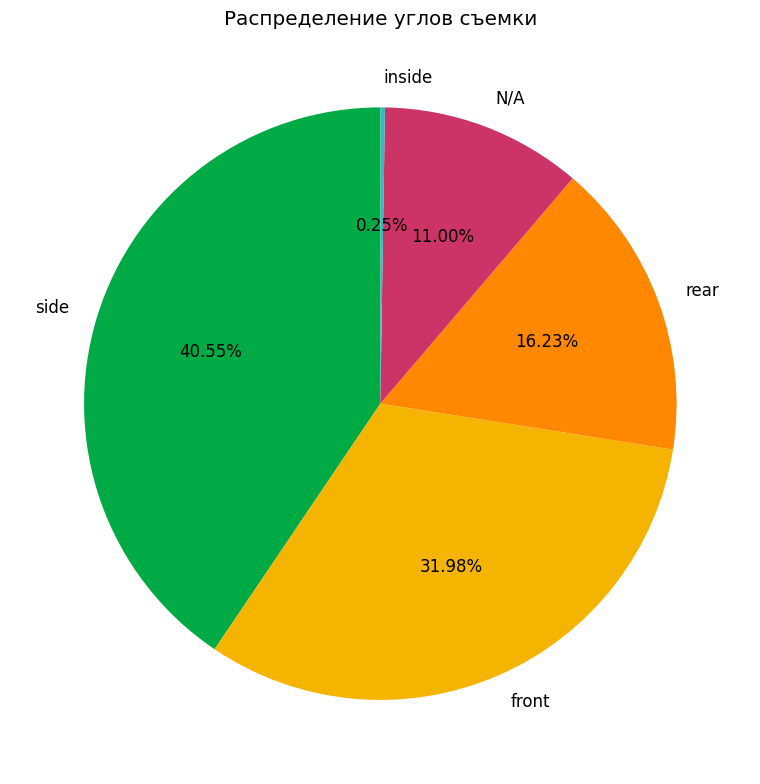

In [ ]:
angle_counts = df["shooting angle"].fillna("N/A").value_counts()


plt.figure(figsize=(8, 8))
plt.pie(
    angle_counts.values,
    labels=angle_counts.index,
    autopct="%1.2f%%",
    startangle=90,
    colors=colors[:len(angle_counts)]
)
plt.title("Распределение углов съемки")
plt.tight_layout()
plt.savefig("shooting_angle_dist.png", dpi=300)
plt.show()

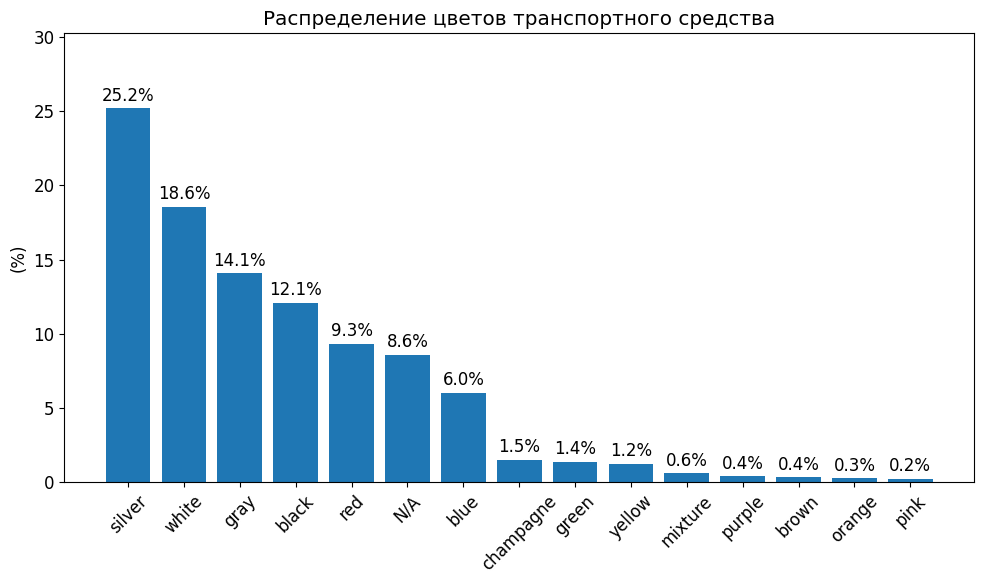

In [ ]:
color_counts = df["color"].fillna("N/A").value_counts(normalize=True) * 100

plt.figure(figsize=(10, 6))
bars = plt.bar(color_counts.index, color_counts.values)

for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, h + 0.5, f"{h:.1f}%", ha="center")

plt.ylabel("(%)")
plt.title("Распределение цветов транспортного средства")
plt.ylim(0, max(color_counts.values) * 1.2)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("vehicle_color_dist.png", dpi=300)
plt.show()

/tmp/ipykernel_2468/3306527742.py:35: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.text(i, bottom[i] + v/2, f'{p:.0f}%\n({int(v)})', ha='center', va='center', fontsize=8, color='white', fontweight='bold')
/tmp/ipykernel_2468/3306527742.py:39: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.text(i, bottom[i] + 5, f'n={int(total)}', ha='center', va='bottom', fontsize=9)
/tmp/ipykernel_2468/3306527742.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


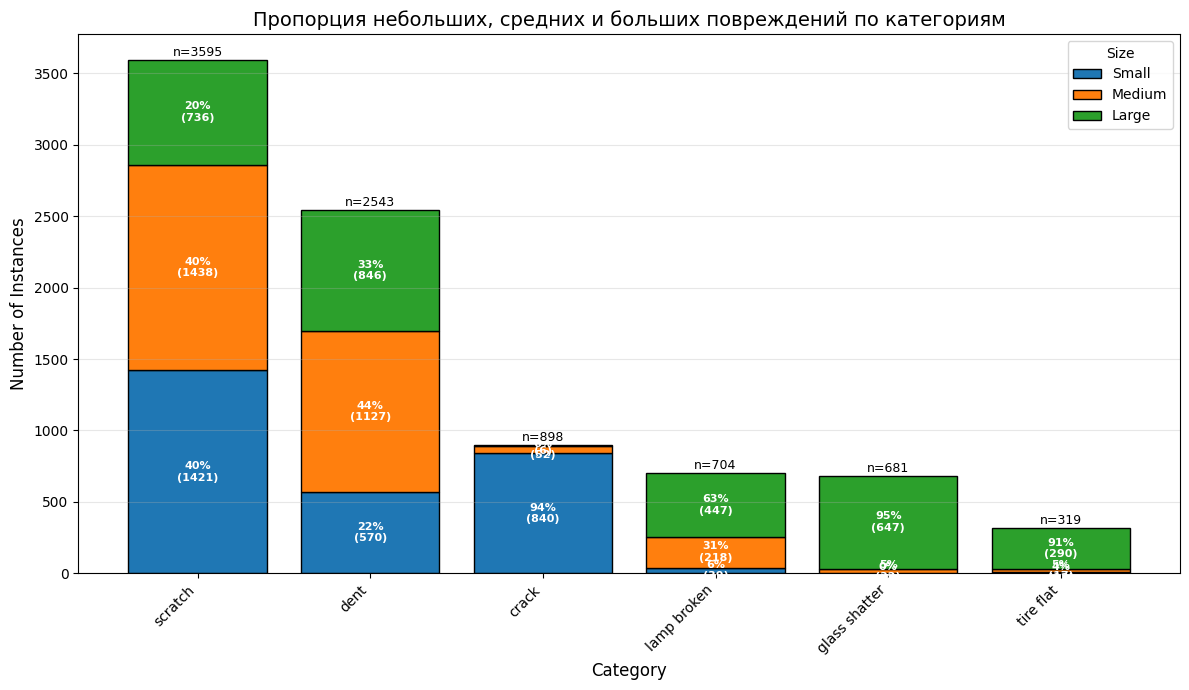

In [23]:
def load_annotations(json_file):
    with open(json_file, 'r') as f:
        data = json.load(f)
    img_info = {img['id']: img['file_name'] for img in data['images']}
    cat_map = {cat['id']: cat['name'] for cat in data['categories']}
    result = []
    for ann in data['annotations']:
        fname = img_info[ann['image_id']].replace('.jpg', '').zfill(6)
        result.append({'file_name': fname, 'category': cat_map[ann['category_id']], 'area': ann['area']})
    return pd.DataFrame(result)

df_train = load_annotations('instances_train2017.json')
df_val = load_annotations('instances_val2017.json')
df_test = load_annotations('instances_test2017.json')
df_ann = pd.concat([df_train, df_val, df_test], ignore_index=True)

q33, q66 = df_ann['area'].quantile([0.33, 0.66])
df_ann['size'] = df_ann['area'].apply(lambda x: 'small' if x <= q33 else ('medium' if x <= q66 else 'large'))

stats = df_ann.groupby(['category', 'size']).size().unstack(fill_value=0)
stats['total'] = stats.sum(axis=1)
stats_pct = stats.div(stats['total'], axis=0) * 100
stats = stats.sort_values('total', ascending=False)
stats_pct = stats_pct.loc[stats.index]

fig, ax = plt.subplots(figsize=(12, 7))
bottom = np.zeros(len(stats))

for size_cat in ['small', 'medium', 'large']:
    vals = stats[size_cat]
    pcts = stats_pct[size_cat]
    ax.bar(stats.index, vals, bottom=bottom, label=size_cat.capitalize(), edgecolor='black')
    for i, (v, p) in enumerate(zip(vals, pcts)):
        if v > 0:
            ax.text(i, bottom[i] + v/2, f'{p:.0f}%\n({int(v)})', ha='center', va='center', fontsize=8, color='white', fontweight='bold')
    bottom += vals

for i, total in enumerate(stats['total']):
    ax.text(i, bottom[i] + 5, f'n={int(total)}', ha='center', va='bottom', fontsize=9)

ax.set_title('Пропорция небольших, средних и больших повреждений по категориям', fontsize=14)
ax.set_xlabel('Category', fontsize=12)
ax.set_ylabel('Number of Instances', fontsize=12)
ax.legend(title='Size')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

/tmp/ipykernel_2468/3450965943.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=stats.index, patch_artist=True, showfliers=False)


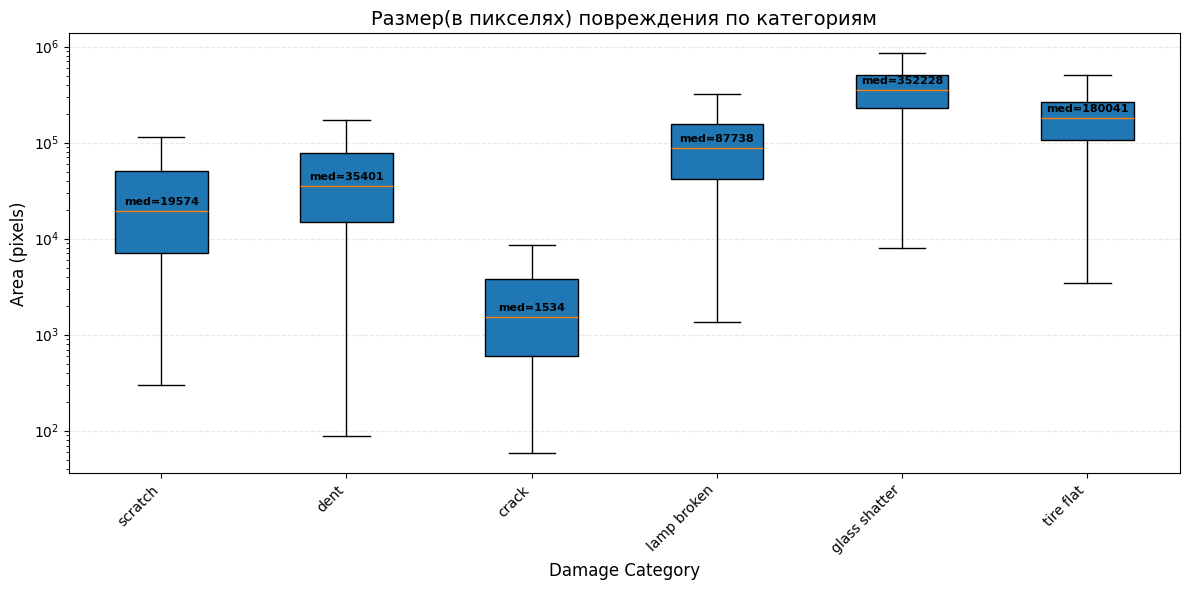

In [22]:
fig, ax = plt.subplots(figsize=(12, 6))

data_to_plot = [df_ann[df_ann['category'] == cat]['area'].values for cat in stats.index]
bp = ax.boxplot(data_to_plot, labels=stats.index, patch_artist=True, showfliers=False)

ax.set_title('Размер(в пикселях) повреждения по категориям', fontsize=14)
ax.set_xlabel('Damage Category', fontsize=12)
ax.set_ylabel('Area (pixels)', fontsize=12)
ax.set_yscale('log')
ax.grid(axis='y', linestyle='--', alpha=0.3)
plt.xticks(rotation=45, ha='right')

for i, cat in enumerate(stats.index):
    median_val = df_ann[df_ann['category'] == cat]['area'].median()
    ax.text(i+1, median_val * 1.1, f'med={median_val:.0f}',
            ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

